In [147]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [148]:
def display(img, camp='gray'):
    fig=plt.figure(figsize=(12,10))
    ax=fig.add_subplot(111)
    ax.imshow(img,cmap='gray')

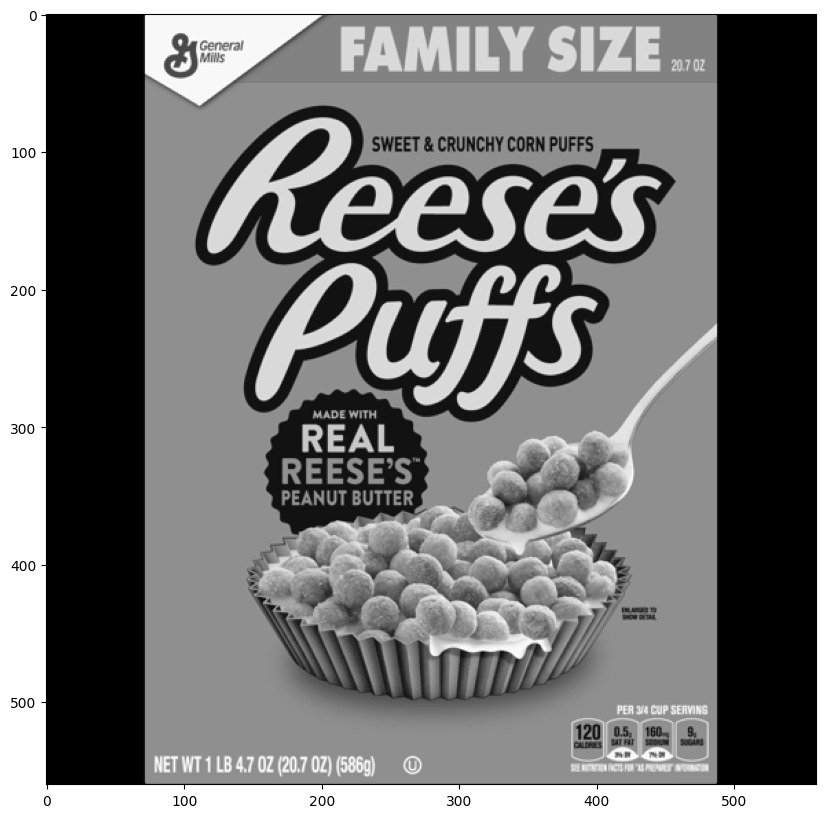

In [149]:
reeses=cv2.imread('../DATA/reeses_puffs.png',0)
display(reeses)

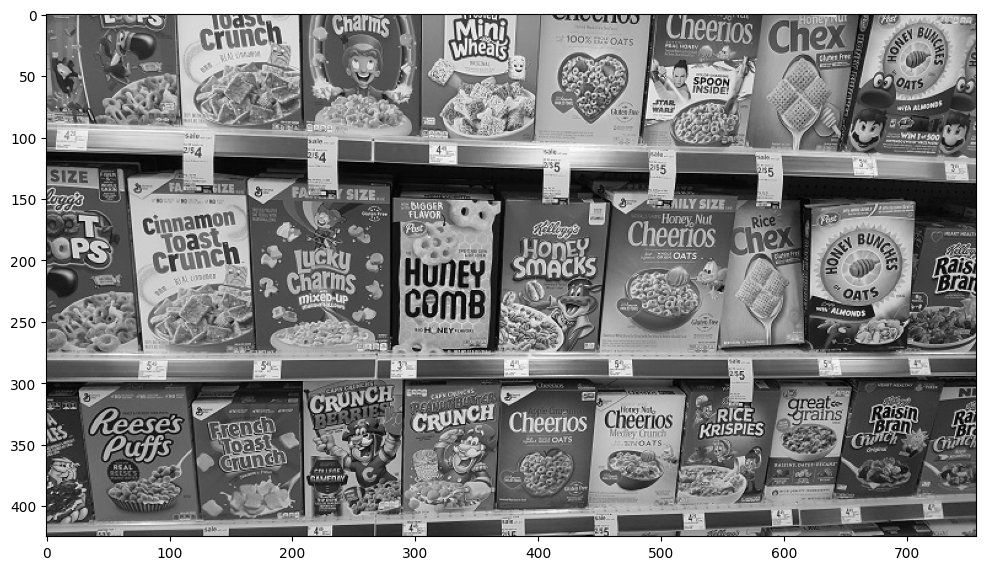

In [150]:
#target image
cereals=cv2.imread('../DATA/many_cereals.jpg',0)
display(cereals)

In [151]:
#Brute Force Detection with ARB descriptors
orb=cv2.ORB_create()

kp1,des1 = orb.detectAndCompute(reeses, None)
kp2,des2 = orb.detectAndCompute(cereals, None)


In [152]:
bf=cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=True)

In [153]:
matches=bf.match(des1,des2)

In [154]:
#slabše kot je ujemanje, večja bo distance
s_match=matches[0]
s_match.distance

56.0

In [155]:
len(matches)

139

In [156]:
# to je namesto for loop in bo rauporedila matches po razdalji (distance)
matches=sorted(matches,key=lambda x:x.distance)

In [157]:
# matches[:25] pomni da bo upoštevalo samo prvih 3 najboljši ujemanj
reeses_matches=cv2.drawMatches(reeses,kp1,cereals,kp2,matches[:3], None,flags=2) 

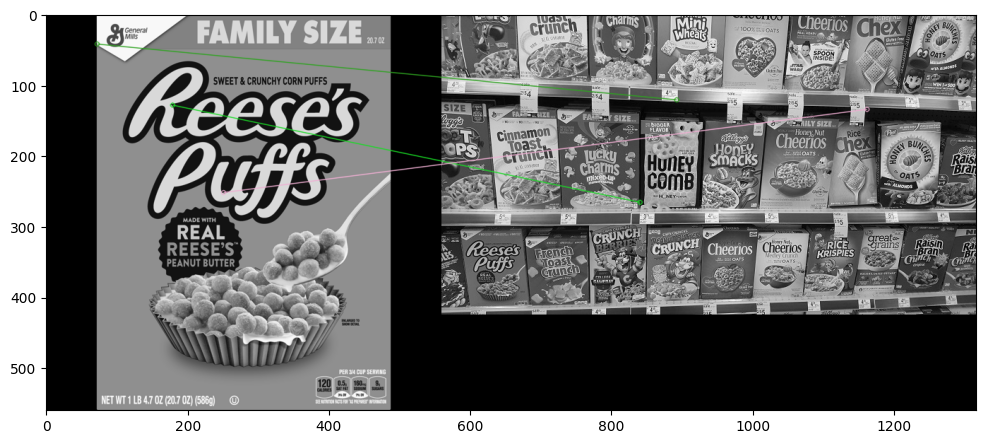

In [158]:
display(reeses_matches)

## Sif descriptors (Scale, Invariant Feature)
it perform well in a different scale of images

In [159]:
# create sift object
sift=cv2.xfeatures2d.SIFT_create()

In [160]:
kp1, des1= sift.detectAndCompute(reeses, None)
kp2, des2= sift.detectAndCompute(cereals, None)

In [161]:
des1

array([[19.,  0.,  0., ...,  1.,  0.,  0.],
       [15.,  0.,  0., ..., 11.,  1.,  0.],
       [21.,  0.,  0., ...,  0., 10., 13.],
       ...,
       [61.,  6.,  0., ...,  0.,  0.,  0.],
       [27.,  0.,  0., ...,  0.,  0.,  0.],
       [48.,  0.,  0., ...,  0.,  1.,  0.]], dtype=float32)

In [162]:
des2

array([[ 0.,  0.,  0., ...,  5.,  1.,  6.],
       [72., 41.,  0., ...,  6.,  0., 13.],
       [ 3.,  1.,  1., ...,  0.,  1., 17.],
       ...,
       [20.,  7., 35., ...,  0.,  0.,  0.],
       [ 4., 54., 81., ...,  0.,  0.,  0.],
       [32.,  2.,  5., ..., 35., 56., 25.]], dtype=float32)

In [163]:
#Calculate Matches
bf=cv2.BFMatcher()
# from descriptors and value K. K is number of bes matches
matches=bf.knnMatch(des1,des2,k=2)

In [164]:
matches

((< cv2.DMatch 000001F2E8C77FB0>, < cv2.DMatch 000001F2E8C76930>),
 (< cv2.DMatch 000001F2E8C760D0>, < cv2.DMatch 000001F2E8C76190>),
 (< cv2.DMatch 000001F2E8C75810>, < cv2.DMatch 000001F2E8C74AF0>),
 (< cv2.DMatch 000001F2E8C74FD0>, < cv2.DMatch 000001F2E8C77D70>),
 (< cv2.DMatch 000001F2E8C74970>, < cv2.DMatch 000001F2E8C75BD0>),
 (< cv2.DMatch 000001F2E8C762D0>, < cv2.DMatch 000001F2E8C768F0>),
 (< cv2.DMatch 000001F2E8C74A30>, < cv2.DMatch 000001F2E8C76910>),
 (< cv2.DMatch 000001F2E8C75F70>, < cv2.DMatch 000001F2E8C75B70>),
 (< cv2.DMatch 000001F2E8C761B0>, < cv2.DMatch 000001F2E8C75DB0>),
 (< cv2.DMatch 000001F2E8C75730>, < cv2.DMatch 000001F2E8C75750>),
 (< cv2.DMatch 000001F2E8C75770>, < cv2.DMatch 000001F2E8C75790>),
 (< cv2.DMatch 000001F2E8C76650>, < cv2.DMatch 000001F2E8C76670>),
 (< cv2.DMatch 000001F2E8C76690>, < cv2.DMatch 000001F2E8C766B0>),
 (< cv2.DMatch 000001F2E8C75D70>, < cv2.DMatch 000001F2E8C75D90>),
 (< cv2.DMatch 000001F2E8C76550>, < cv2.DMatch 000001F2E8C7657

In [165]:
good=[]

# less distance == metter match
# Ratio Match1 < 75% Match 2
for match1, match2 in matches:
    # IF match 1 distance is less than 75% of mathc 2 distance
    # THEN descriptro was a good mathc, lets keep it ! 
    if match1.distance < 0.75*match2.distance:
        good.append([match1])

In [166]:
len(good)

79

In [167]:
len(matches)

1501

In [168]:
good

[[< cv2.DMatch 000001F2E8C77FB0>],
 [< cv2.DMatch 000001F2E8C77070>],
 [< cv2.DMatch 000001F2E8C742F0>],
 [< cv2.DMatch 000001F2E8C74430>],
 [< cv2.DMatch 000001F2E8C740B0>],
 [< cv2.DMatch 000001F2E8C747B0>],
 [< cv2.DMatch 000001F2E8C76090>],
 [< cv2.DMatch 000001F2E8C75A70>],
 [< cv2.DMatch 000001F2E8C77010>],
 [< cv2.DMatch 000001F2E8CDBF50>],
 [< cv2.DMatch 000001F2E8CDAB10>],
 [< cv2.DMatch 000001F2E8CDB710>],
 [< cv2.DMatch 000001F2E8CD9CB0>],
 [< cv2.DMatch 000001F2E8CD9A90>],
 [< cv2.DMatch 000001F2E8CD96B0>],
 [< cv2.DMatch 000001F2E8CDAD10>],
 [< cv2.DMatch 000001F2E8CD8F90>],
 [< cv2.DMatch 000001F2E8CD8630>],
 [< cv2.DMatch 000001F2E8CD8890>],
 [< cv2.DMatch 000001F2E898E850>],
 [< cv2.DMatch 000001F2E898DF70>],
 [< cv2.DMatch 000001F2E898C7F0>],
 [< cv2.DMatch 000001F2E898D850>],
 [< cv2.DMatch 000001F2E898D6D0>],
 [< cv2.DMatch 000001F2E898D150>],
 [< cv2.DMatch 000001F2E898CFD0>],
 [< cv2.DMatch 000001F2E898F5B0>],
 [< cv2.DMatch 000001F2E898DCB0>],
 [< cv2.DMatch 00000

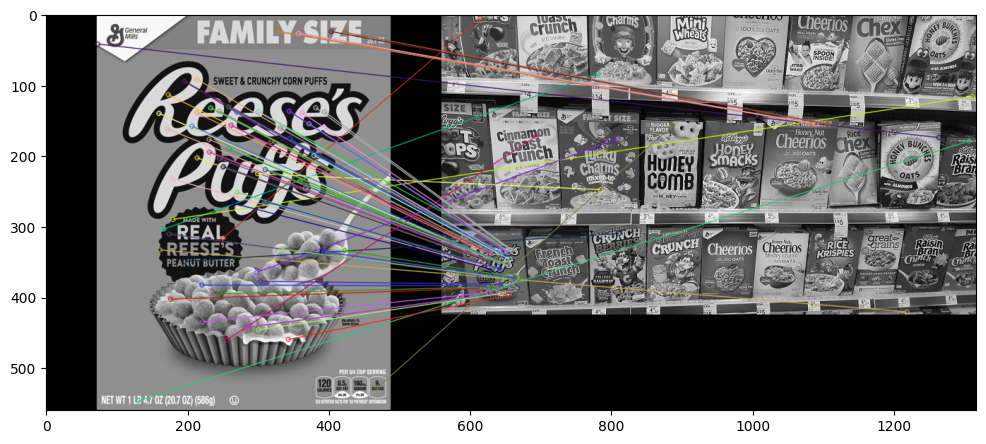

In [169]:
sift_matches=cv2.drawMatchesKnn(reeses,kp1,cereals,kp2,good,None,flags=2)
display(sift_matches)

## Land based matcher


In [170]:
sift=cv2.xfeatures2d.SIFT_create()

kp1, des1= sift.detectAndCompute(reeses, None)
kp2, des2= sift.detectAndCompute(cereals, None)

In [171]:
# FLANN parameters
FLANN_INDEX_DKTREE=0
index_params=dict(algorithm=FLANN_INDEX_DKTREE,trees=5)
search_params=dict(cheks=50)

flann=cv2.FlannBasedMatcher(index_params, search_params)

In [172]:
matches=flann.knnMatch(des1,des2,k=2)

In [173]:
matchesMask = [[0,0] for i in range(len(matches))]


In [183]:
for i,(match1, match2) in enumerate(matches):
    if match1.distance < 0.7*match2.distance:
        matchesMask[i]=[1,0]



In [184]:
draw_params=dict(matchColor=(0,255,0), singlePointColor=(255,0,0), matchesMask=matchesMask, flags=0)


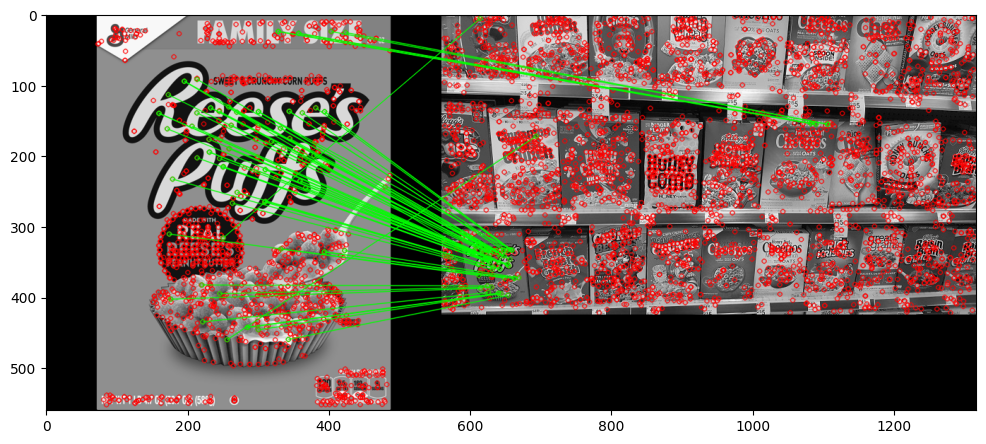

In [185]:
flann_matches=cv2.drawMatchesKnn(reeses,kp1,cereals,kp2,matches,None,**draw_params)
display(flann_matches)